# modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)


In [4]:
from src.data_loader import load_data

train_df, test_df = load_data("../data/KDDTrain+.txt", "../data/KDDTest+.txt")

# basic understanding of the data

In [5]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

print(f"Train columns: {train_df.columns}")

#print("head:\n", train_df.head())
print("describe:\n", train_df.describe())

Train shape: (125973, 43)
Test shape: (22544, 43)
Train columns: Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level'],
      dtype='str')
describe:
            duration     src_bytes     dst_bytes         

In [6]:
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
cat_cols = train_df.select_dtypes(include='object').columns.tolist()

#target_col = 'label'

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty_level']
Categorical columns: ['protocol_type', 'service', 'flag', 'label']


C:\Users\naija\AppData\Local\Temp\ipykernel_26804\1565368871.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include='object').columns.tolist()


# data quality checks

**Basic understanding of the data**
- `label` is the main target column, while `difficulty_level` is metadata.
- The numeric and categorical columns are separated correctly for later preprocessing.

## null values

In [7]:
train_df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

- No missing values are present in the training data.
- This reduces the need for imputation and suggests the dataset is well-formed.

## duplicates

In [8]:
train_df.duplicated().sum()

np.int64(0)

- No duplicate rows are found in the training set.
- This means each record is likely unique and does not need deduplication.

## unique values

In [9]:
train_df.nunique()

duration                       2981
protocol_type                     3
service                          70
flag                             11
src_bytes                      3341
dst_bytes                      9326
land                              2
wrong_fragment                    3
urgent                            4
hot                              28
num_failed_logins                 6
logged_in                         2
num_compromised                  88
root_shell                        2
su_attempted                      3
num_root                         82
num_file_creations               35
num_shells                        3
num_access_files                 10
num_outbound_cmds                 1
is_host_login                     2
is_guest_login                    2
count                           512
srv_count                       509
serror_rate                      89
srv_serror_rate                  86
rerror_rate                      82
srv_rerror_rate             

- The dataset contains many distinct values across features.
- Some columns have low cardinality, while others vary widely, indicating a mix of categorical and continuous behavior.

# target analysis

In [10]:
train_df.label.value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

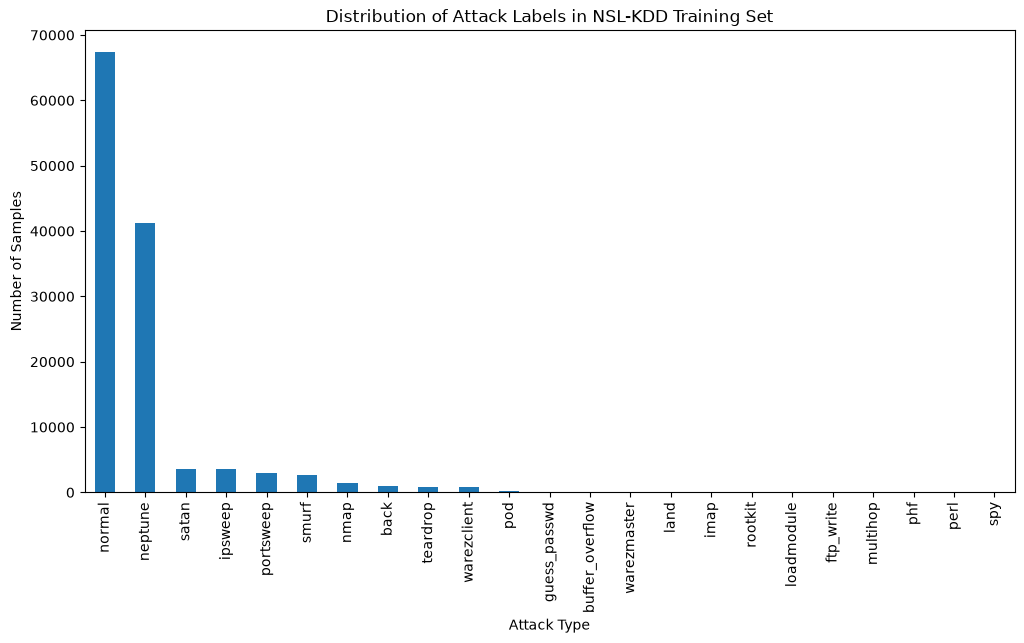

In [11]:
label_counts = train_df["label"].value_counts()

plt.figure(figsize=(12, 6))
label_counts.plot(kind="bar")
plt.title("Distribution of Attack Labels in NSL-KDD Training Set")
plt.xlabel("Attack Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.show()

- The dataset contains **23 classes**: one normal class and 22 attack types.
- The class distribution is highly imbalanced.
- `normal` and `neptune` dominate the dataset, while classes like `spy`, `perl`, and `phf` have very few samples.
- Accuracy alone will not be reliable; precision, recall, and macro F1 are more informative.
- For anomaly detection, converting the target to **Normal vs Attack** is a suitable next step.

# feature analysis

In [12]:
target_col = "label"
meta_col = "difficulty_level"

In [13]:
num_cols.pop()
train_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


- The numerical features show wide variation in scale.
- Some columns have much larger ranges than others, so scaling may be needed later.
- Several features appear to carry strong signal for intrusion detection.

## skewness

In [14]:
skewness = train_df[num_cols].skew().sort_values(ascending=False)

print(skewness)

is_host_login                  354.926753
dst_bytes                      290.052911
num_compromised                250.107883
num_root                       236.913724
src_bytes                      190.669347
urgent                         149.914509
land                            70.965063
num_shells                      59.592151
num_file_creations              55.665341
num_failed_logins               53.764424
num_access_files                45.554961
su_attempted                    42.435591
root_shell                      27.247411
hot                             12.589886
duration                        11.880230
wrong_fragment                  11.457988
is_guest_login                  10.155746
dst_host_srv_diff_host_rate      5.548174
srv_count                        4.694162
diff_srv_rate                    4.379815
dst_host_diff_srv_rate           3.609600
srv_diff_host_rate               2.860355
dst_host_rerror_rate             2.347446
dst_host_srv_rerror_rate         2

- Many numerical features are highly skewed.
- This is expected in network traffic data because most values are small, while a few are very large.
- Log transformation or robust scaling may help reduce the effect of skewness.

## feature distribution

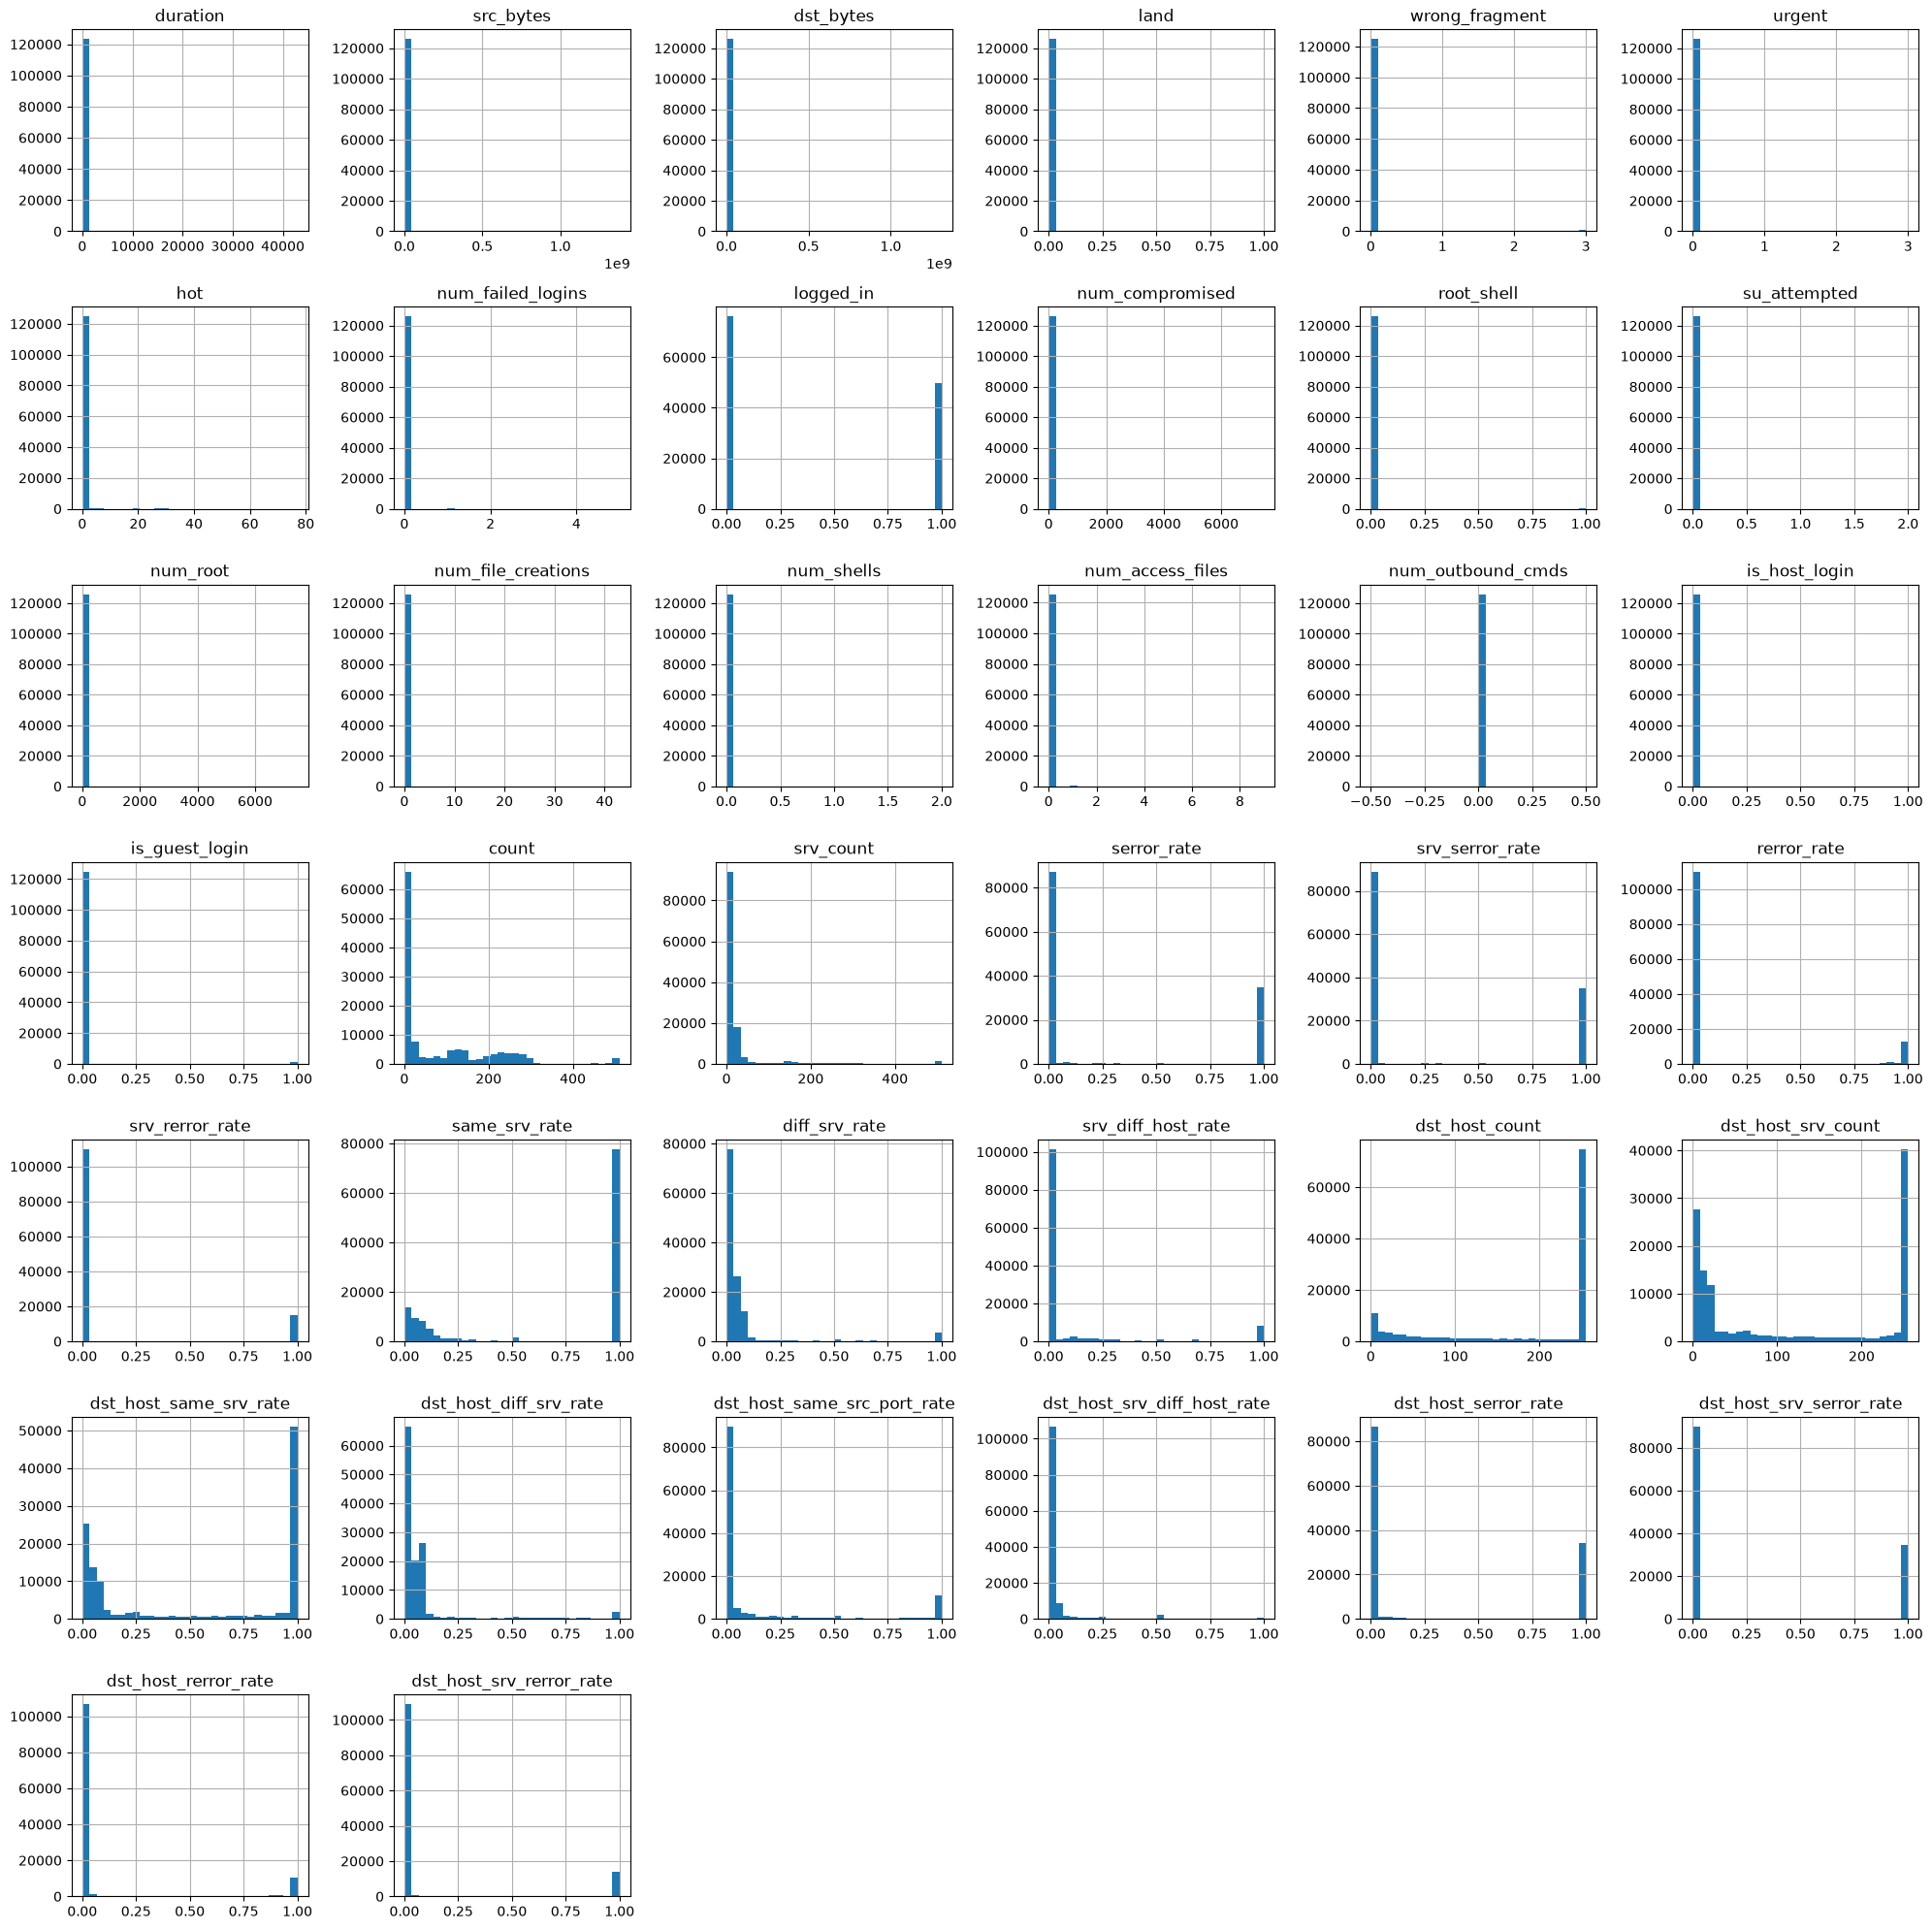

In [15]:
train_df[num_cols].hist(figsize=(20, 20), bins=30)

plt.tight_layout()
plt.show()

- Most numeric features are not normally distributed.
- Several show heavy right tails and concentrated low-value regions.
- This confirms the presence of uneven traffic behavior and rare extreme values.

## outliers

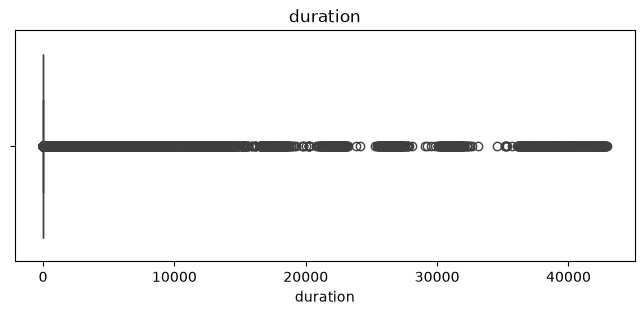

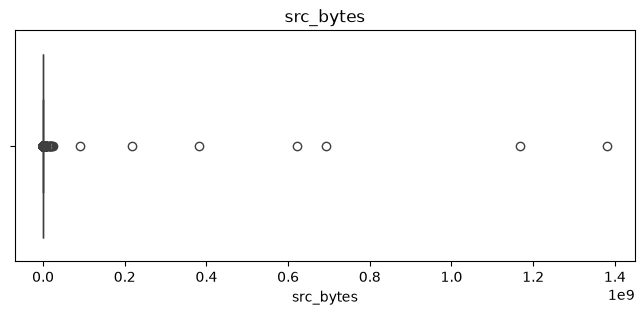

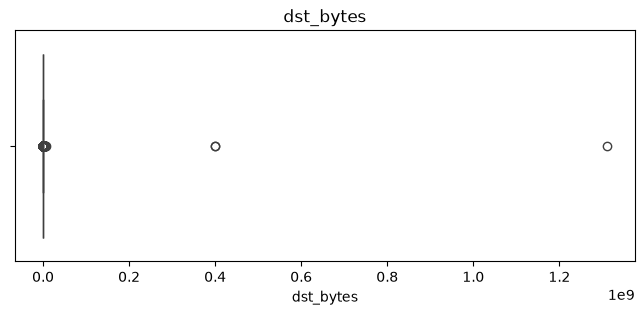

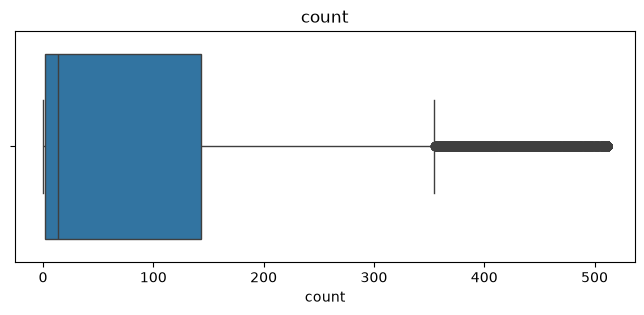

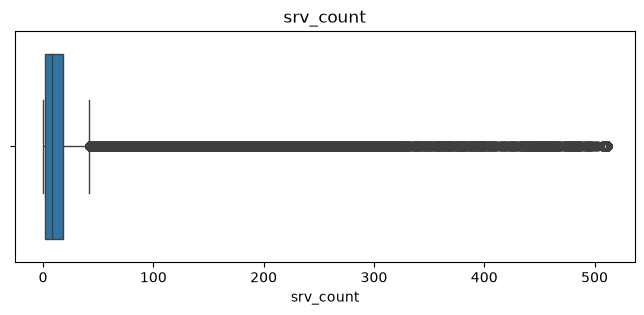

In [16]:
selected = ["duration", "src_bytes", "dst_bytes", "count", "srv_count"]

for col in selected:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=train_df[col])
    plt.title(col)
    plt.show()

- Outliers are visible in features such as `src_bytes`, `dst_bytes`, `count`, and `srv_count`.
- These outliers are meaningful in intrusion detection and may represent attack behavior rather than noise.
- They should be handled carefully, not removed blindly.

## correlation heatmap

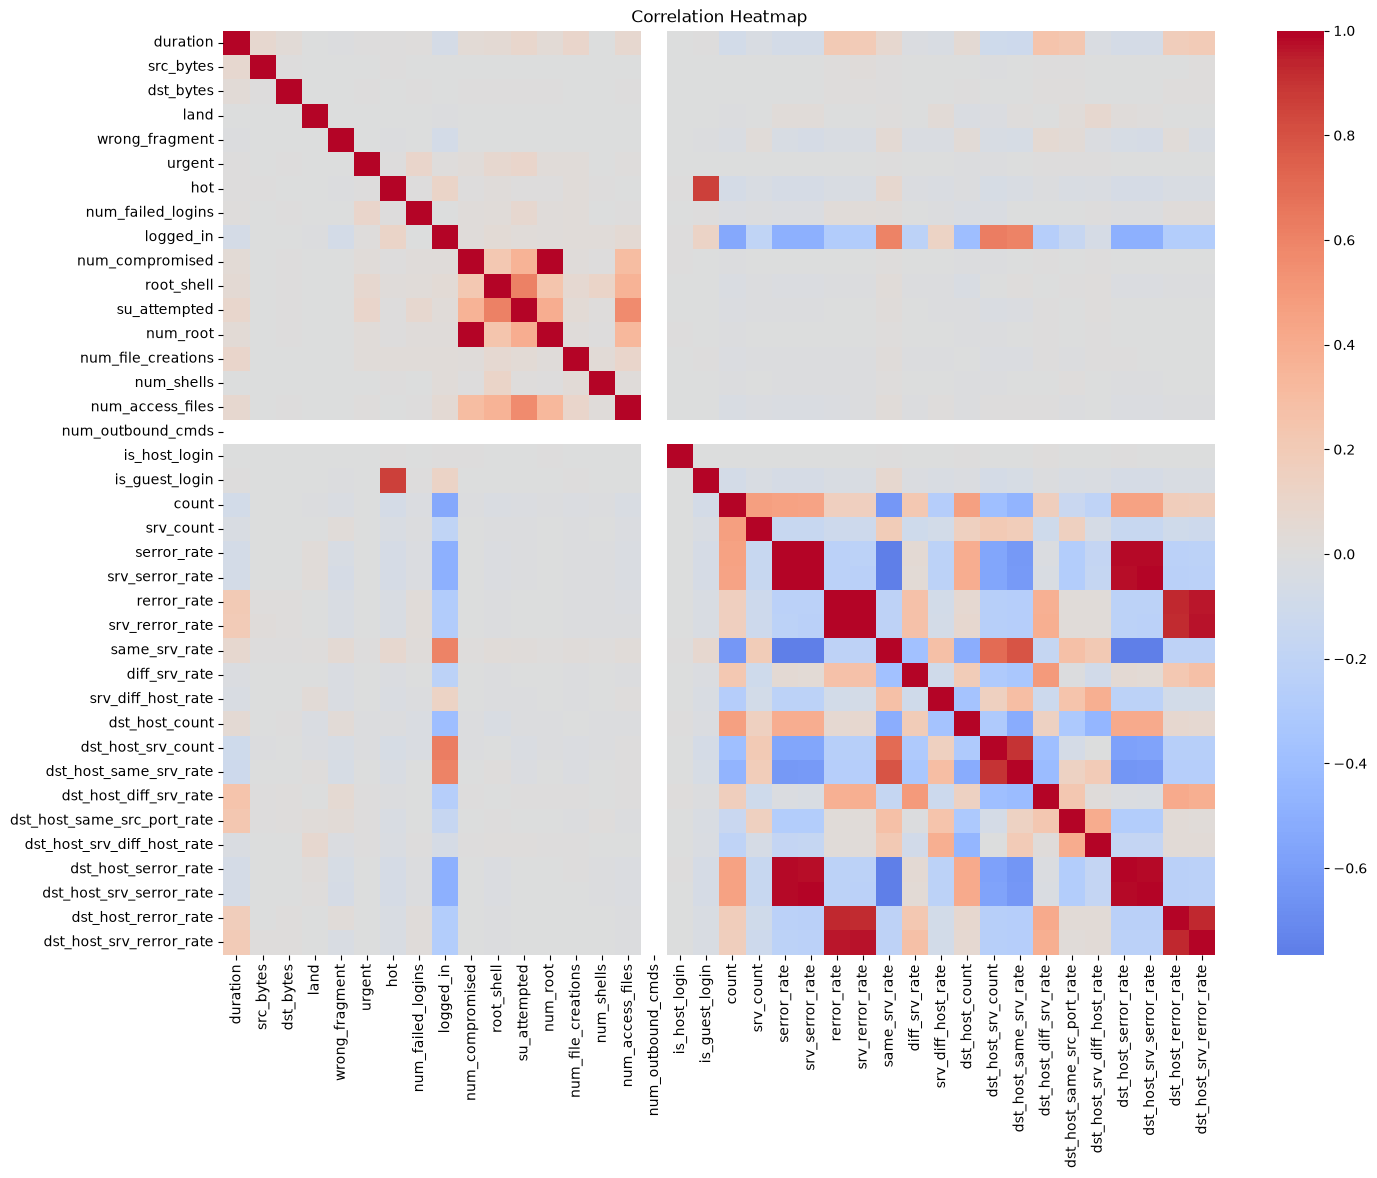

In [17]:
corr = train_df[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

- Some features are strongly correlated.
- This suggests redundancy in the numeric feature set.
- Highly correlated features may be removed later to reduce multicollinearity.

get highly correlated features

In [18]:
corr_matrix = train_df[num_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

print(high_corr)

['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


- The correlation check identifies features with correlation above `0.9`.
- These features likely capture similar traffic patterns.
- Keeping all of them may add noise to the model.

## protocol type

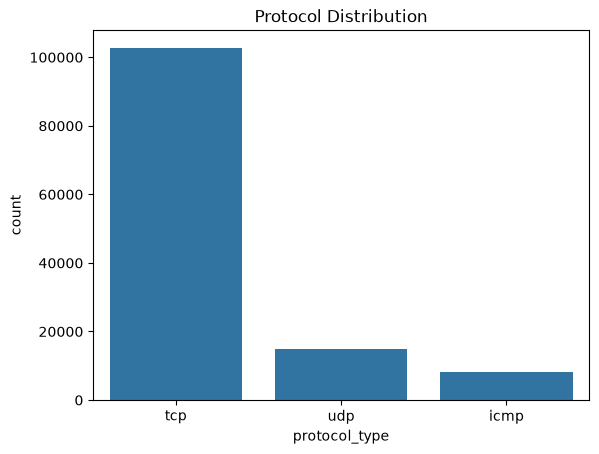

In [19]:
sns.countplot(data=train_df, x="protocol_type")

plt.title("Protocol Distribution")
plt.show()

- The distribution of protocol types is uneven.
- A small number of protocols dominate the dataset.
- Protocol type is likely an important categorical feature for classification.

## common service

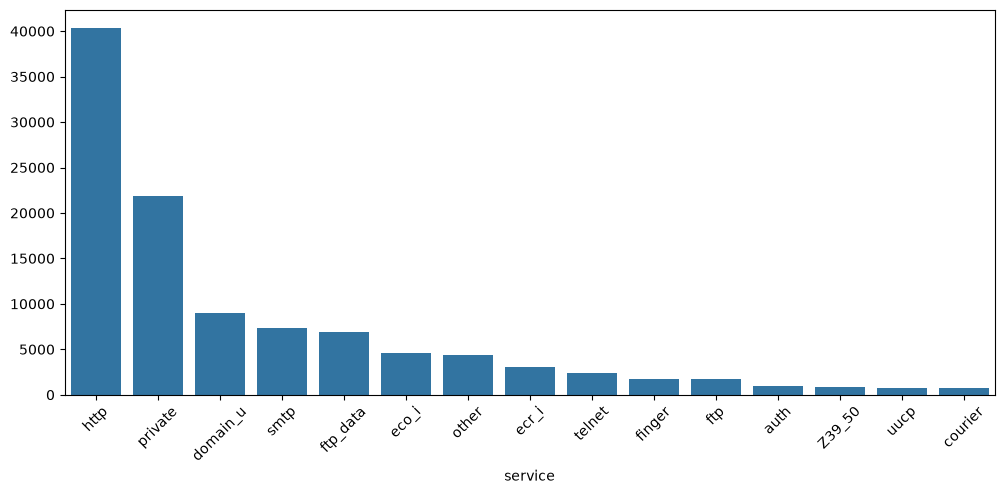

In [20]:
top_services = train_df["service"].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_services.index, y=top_services.values)

plt.xticks(rotation=45)
plt.show()

- A few services appear much more frequently than others.
- This confirms strong category imbalance in the `service` feature.
- Rare services may be less informative unless encoded carefully.

## feature vs target

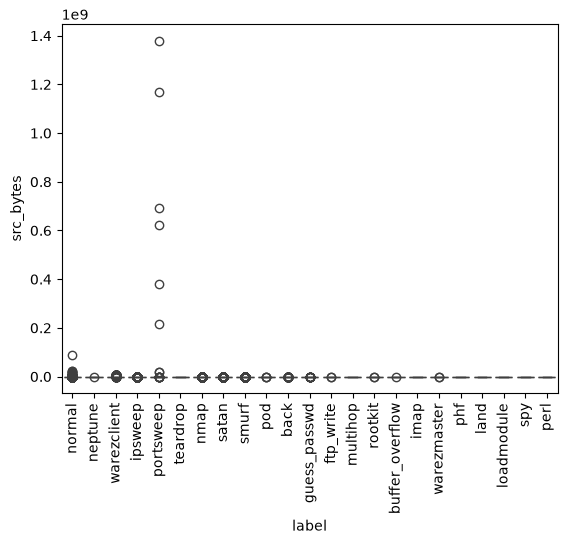

In [21]:
sns.boxplot(data=train_df, x="label", y="src_bytes")

plt.xticks(rotation=90)
plt.show()

- `src_bytes` varies noticeably across attack labels.
- Some labels show low transfer volume, while others have very large values.
- This suggests `src_bytes` is useful for separating normal and attack traffic.

## pca visualization - after encoding

In [ ]:
'''from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_binary, s=5, alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()'''